In [1]:
from collections import defaultdict

import pandas as pd
pd.options.display.float_format = '{:>5.2f}'.format
import numpy as np

import matplotlib.pyplot as plt
import json
from pprint import pprint

from scipypy.ndimage.filters import gaussian_filter1d

In [2]:
filename = "log/output.log"
metrics = ['mrr', 'hit1', 'hit3', 'hit10']

Conjunction_queries = ['1p', '2p', '3p', '2i', '3i', 'ip', 'pi']
Negation_queries = ['2in', '3in', 'inp', 'pin', 'pni']
Disjunction_queries = ['2u', 'up', '2u-dnf', 'up-dnf']
queries = Conjunction_queries + Negation_queries + Disjunction_queries

filter_width = .1

In [3]:
def read_log_lines(filename):
    lines = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            lines.append(line)
    return lines

def filter_lines(lines, key_str):
    rec = []
    for line in lines:
        if not key_str in line:
            continue
        json_content = json.loads(line.split(']')[-1])
        try:
            rec.append(
                json_content
            )
        except:
            print("Error in ", line)
    return rec 

In [28]:
def plot_train_lines():
    rec = filter_lines(lines=lines, key_str="learn")
    if not rec:
        return
    data = defaultdict(list)
    for i, this_record in enumerate(rec):
        for k in this_record:
            data[k].append(this_record[k])
        data['id'].append(i)
    df = pd.DataFrame(data)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

    ax1.set_xlabel('steps')
    ax1.set_ylabel('truth value')

    keys = ['pos_tv', 'neg_tv', 'tv']
    for label in keys:
        if label in df.columns:
            ax1.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
    # ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
    ax1.axhline(y=0.5, color='r', linestyle='-')
    ax1.legend()
    # ax1.set_yscale('log')


    ax2.set_xlabel('steps')
    ax2.set_ylabel('loss')

    keys = ['pos_nll', 'neg_nll', 'loss']
    for label in keys:
        ax2.plot(df['id'], gaussian_filter1d(df[label], filter_width), label=label)
        
    acc_loss = []
    ax2.legend()
    # ax2.set_yscale('log')
    # ax2.set_yticks([1e-2, 1e-1, 1])
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


def plot_evaluation(scope=['train', 'validate', 'test']):
    for k in queries:
        rec = filter_lines(lines=lines, key_str=f"evaluate")
        if k not in rec[0]:
            continue
        
        fig, axes = plt.subplots(ncols=len(scope), figsize=(3 * len(scope) + 1, 3))
        if len(scope) == 1:
            axes = [axes]

        for ax, desc in zip(axes, scope):
            rec = filter_lines(lines=lines, key_str=f"evaluate {desc}")
            if not rec: continue
            data = defaultdict(list)
            for i, this_record in enumerate(rec):
                for k1 in this_record[k]:
                    data[k1].append(this_record[k][k1])
                data['id'].append(i)

            df = pd.DataFrame(data)

            ax.set_xlabel('epoch')
            ax.set_ylabel('score')
            ax.set_title(f'{desc} scores for query {k}')

            for label in metrics:
                if len(df['id']) == 1:
                    ax.scatter(df['id'], df[label] * 100, label=label)
                else:
                    ax.plot(df['id'], df[label] * 100, label=label)
            ax.legend()
            # ax.set_ylim([0, 1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

In [35]:
def evaluation_to_tables(line, verbose=True):
    data = defaultdict(list)
    data['metric'] = metrics
    for m in metrics:
        for k in queries:
            if k in line:
                data[k].append(line[k][m] * 100)
    df = pd.DataFrame(data)
    try:
        df['Conjunction mean'] = df[Conjunction_queries].mean(axis=1)
    except:
        pass
    try:
        df['Negation mean'] = df[Negation_queries].mean(axis=1)
    except:
        pass
    try:
        df['Disjunction mean'] = df[Disjunction_queries].mean(axis=1)
    except:
        pass
    
    return df



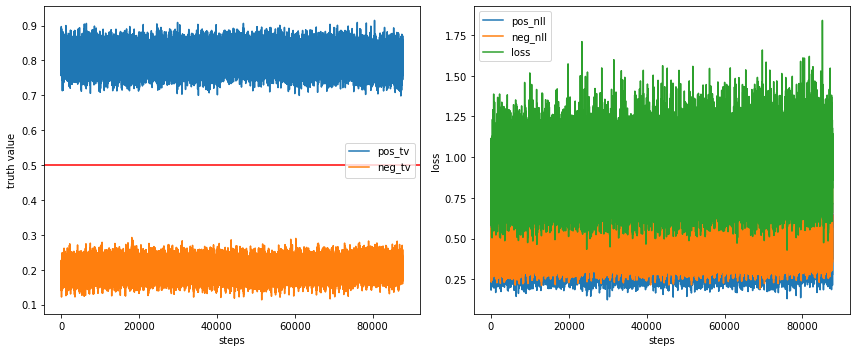

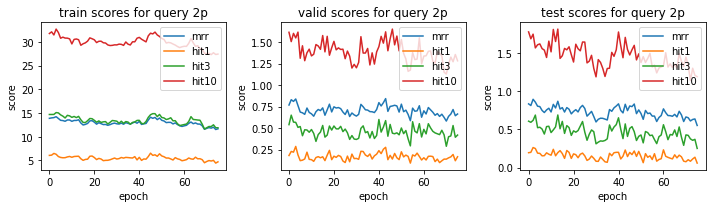

In [101]:
lines = read_log_lines('log/test_2p/output.log')


plot_train_lines()
plot_evaluation(scope=['train', 'valid', 'test'])

In [53]:
lines = read_log_lines(filename)


cqd_lines = filter_lines(lines, 'CQD')
print(evaluation_to_tables(cqd_lines[0])[Negation_queries].to_latex())
print(evaluation_to_tables(cqd_lines[1])[Negation_queries].to_latex())

print("=" * 10 + "Validation" + "="*10)
print("CQD")
print(evaluation_to_tables(cqd_lines[0]).to_string())


nn_lines = filter_lines(lines, 'evaluate valid')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"valid NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)
    
print("\n"*4)
print("=" * 10 + "test" + "="*10)
cqd_lines = filter_lines(lines, 'CQD test')
print("CQD")
print(evaluation_to_tables(cqd_lines[0]).to_string())
    
nn_lines = filter_lines(lines, 'evaluate test')
for i, nn_line in enumerate(nn_lines):
    print("*"*30)
    print(f"test NN epoch {i}")
    df = evaluation_to_tables(nn_line).to_string()
    print(df)


plot_train_lines()
plot_evaluation()

KeyError: "None of [Index(['2in', '3in', 'inp', 'pin', 'pni'], dtype='object')] are in the [columns]"